This code is going to be adapted from the earlier toy loading code which only used four images to use all the images from the Great UK Water Blitz. 

In [1]:
#Import modules
#common
import os
import keras
from tqdm import tqdm
from glob import glob
import tensorflow as tf
from numpy import zeros
from numpy.random import randint
import numpy as np
from PIL import Image, ImageOps #PIL is depreciated, Pillow is actively maintained. 
from PIL import UnidentifiedImageError #Catch bad images
import PIL.ExifTags
import matplotlib.pyplot as plt
import csv
from matplotlib import cm
import time, sys

# Data
from tensorflow.image import resize
from keras.preprocessing.image import load_img, img_to_array

# Data Viz
import matplotlib.pyplot as plt

# Model
from keras.layers import add
from keras.layers import Input
from keras.layers import Layer
from keras.layers import Conv2D
from keras.layers import multiply
from keras.layers import concatenate
from keras.layers import Conv2DTranspose
from keras.layers import MaxPool2D
from keras.layers import UpSampling2D
from keras.layers import BatchNormalization
from keras.layers import Dropout

# Model Functions
from keras.callbacks import EarlyStopping
from keras.models import Model
from tensorflow.keras.utils import plot_model
from keras.callbacks import Callback, ModelCheckpoint
from tensorflow.keras.utils import register_keras_serializable

#Defining a function to show the images
def show_image(image, title=None):
    plt.imshow(image)
    plt.title(title)
    plt.axis('off')

#Defining a function to load in the images and convert to arrays
def load_image(path):
    img = load_img(path)
    img = ImageOps.exif_transpose(img)
    img = resize(img_to_array(img)/255., (224,224))
    return img

#Defining a function to load in the data
def load_data(paths):
    start_time = time.time()
    images = []
    valid_paths = []

    for path in tqdm(paths, desc="Loading"):
        if time.time() - start_time > 180:
            sys.exit("Time limit reached, exiting")
            return images
        try:
            image = load_image(path)
            images.append(image)
            valid_paths.append(path)
        except (UnidentifiedImageError, OSError) as e:
            print(f"Skipping invalid image: {path}")
    return images

#Setting up the model structure (encoder and decoder classes)
#Encoder
@register_keras_serializable()
class Encoder(Layer):

    def __init__(self, filters, rate, pooling=True, **kwargs):
        super(Encoder, self).__init__(**kwargs)

        self.filters = filters
        self.rate = rate
        self.pooling = pooling

        self.bn = BatchNormalization()
        self.c1 = Conv2D(filters, kernel_size=3, padding='same', activation='relu', kernel_initializer="he_normal")
        self.drop = Dropout(rate)
        self.c2 = Conv2D(filters, kernel_size=3, padding='same', activation='relu', kernel_initializer="he_normal")
        self.pool = MaxPool2D()

    def call(self, X):
        x = self.bn(X)
        x = self.c1(x)
        x = self.drop(x)
        x = self.c2(x)
        if self.pooling:
            y = self.pool(x)
            return y, x
        else:
            return x

    def get_config(self):
        base_config = super().get_config()
        return {
            **base_config,
            "filters":self.filters,
            "rate":self.rate,
            "pooling":self.pooling
        }
#Decoder
@register_keras_serializable()
class Decoder(Layer):

    def __init__(self, filters, rate, **kwargs):
        super(Decoder, self).__init__(**kwargs)

        self.filters = filters
        self.rate = rate

        self.bn = BatchNormalization()
        self.cT = Conv2DTranspose(filters, kernel_size=3, strides=2, padding='same', activation='relu', kernel_initializer="he_normal")
        self.net = Encoder(filters, rate, pooling=False)

    def call(self, X):
        x, skip_x = X
        x = self.bn(x)
        x = self.cT(x)
        x = concatenate([x, skip_x])
        x = self.net(x)
        return x

    def get_config(self):
        base_config = super().get_config()
        return {
            **base_config,
            "filters":self.filters,
            "rate":self.rate,
        }



2026-01-12 16:13:26.617151: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-12 16:13:27.172005: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-12 16:13:28.800248: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
#Load the best model
UNet = tf.keras.models.load_model(
    "models/UNet_best_bs8.keras",
    custom_objects={"Encoder": Encoder, "Decoder": Decoder},
    compile=True   
)

#Set the path where the photos are
my_image_path="/home/teaching/earthwatch-cnn/data/Great_UK_water_blitz/"
total_images = len(os.listdir(my_image_path))
print(f"Total Number of Images : {total_images}")
my_paths=sorted(glob(my_image_path + "/*.jpg"))
my_paths=my_paths[:-1]
n_files=len(my_paths)
delta_checkpoints=n_files//20 #want to print 20 images
checkpoints=np.arange(0,n_files, delta_checkpoints)

2026-01-12 16:13:30.802127: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/teaching/earthwatch-cnn/earthwatch-cnn/lib/python3.10/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'Encoder1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/home/teaching/earthwatch-cnn/earthwatch-cnn/lib/python3.10/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'Encoder2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause fa

Total Number of Images : 9048


In [3]:
start_time = time.time() #Had to add this because VS code/the terminal keeps crashing after the data loading gets to 100% and I am not sure how to stop this. 

#Load in the images
X_values = load_data(my_paths)
if time.time() - start_time > 180:
    sys.exit("Time limit reached, exiting")

Loading:   1%|▏         | 100/7047 [00:02<02:26, 47.27it/s]

Skipping invalid image: /home/teaching/earthwatch-cnn/data/Great_UK_water_blitz/Feature_10134_Attachment_8825_photo_20250921191348.jpg


Loading:  35%|███▍      | 2457/7047 [00:38<01:09, 65.93it/s]

Skipping invalid image: /home/teaching/earthwatch-cnn/data/Great_UK_water_blitz/Feature_4056_Attachment_3341_photo_20250425104337.jpg


Loading:  40%|████      | 2832/7047 [00:44<01:11, 59.10it/s]

...

Loading:  65%|██████▌   | 4581/7047 [01:13<00:35, 68.83it/s]

Skipping invalid image: /home/teaching/earthwatch-cnn/data/Great_UK_water_blitz/Feature_6697_Attachment_5759_photo_20250428111041.jpg


Loading:  65%|██████▌   | 4605/7047 [01:13<00:33, 73.26it/s]

Skipping invalid image: /home/teaching/earthwatch-cnn/data/Great_UK_water_blitz/Feature_6718_Attachment_5780_photo_20250428112612.jpg


Loading: 100%|██████████| 7047/7047 [01:52<00:00, 62.37it/s]


  0%|          | 0/7039 [00:00<?, ?it/s]

Index 0, fraction positive mask = 0.2869
saved


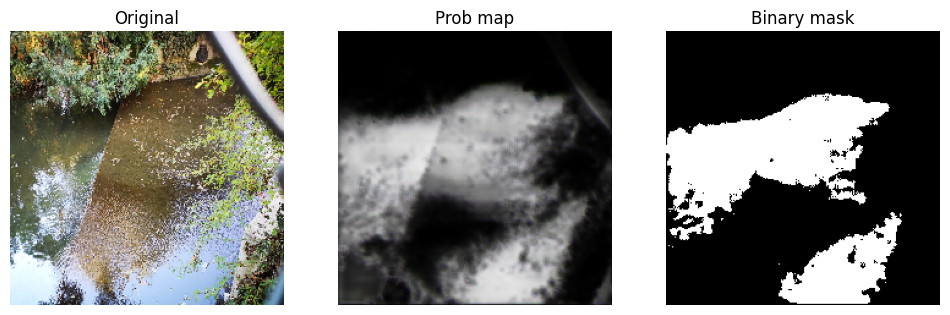

  0%|          | 1/7039 [00:00<52:18,  2.24it/s]

No water: 0


  2%|▏         | 140/7039 [01:14<1:13:36,  1.56it/s]

Index 140, fraction positive mask = 0.0000


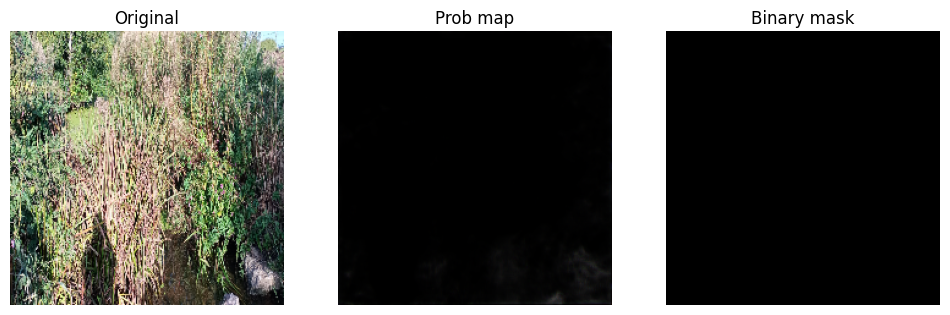

  2%|▏         | 141/7039 [01:15<1:22:02,  1.40it/s]

No water: 65


  4%|▍         | 280/7039 [02:36<1:03:16,  1.78it/s]

Index 280, fraction positive mask = 0.2480
saved


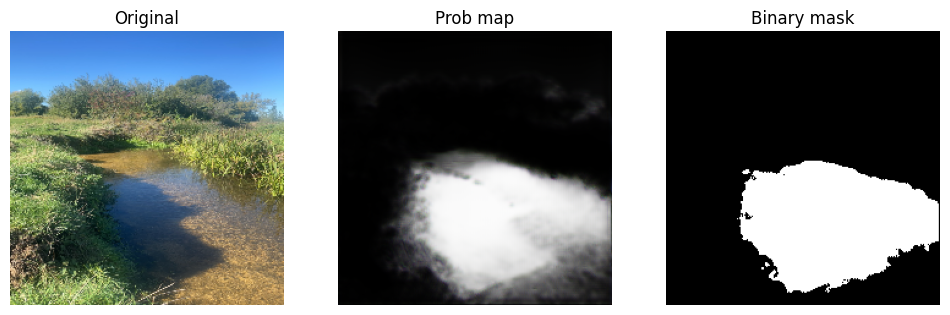

  4%|▍         | 281/7039 [02:37<1:30:43,  1.24it/s]

No water: 116


  6%|▌         | 420/7039 [03:50<55:15,  2.00it/s]  

Index 420, fraction positive mask = 0.1468
saved


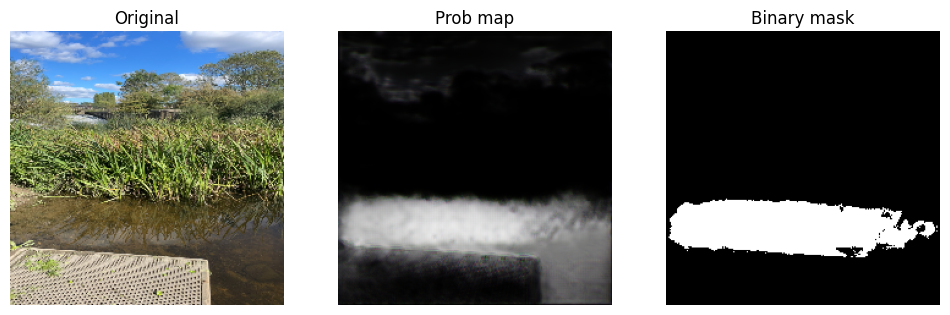

  6%|▌         | 421/7039 [03:51<1:00:43,  1.82it/s]

No water: 170


  8%|▊         | 560/7039 [05:01<52:29,  2.06it/s]  

Index 560, fraction positive mask = 0.0428


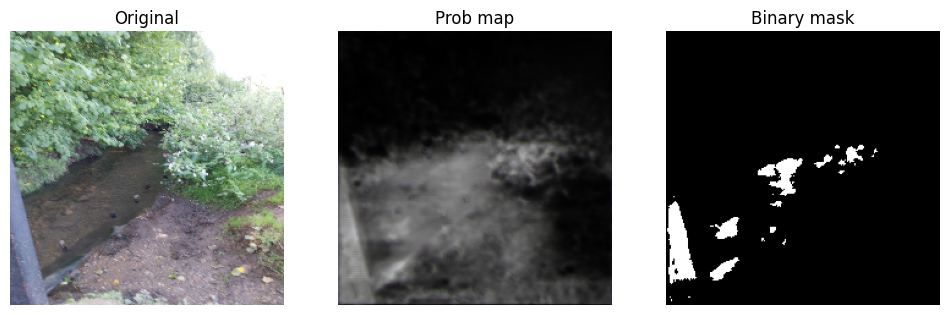

  8%|▊         | 561/7039 [05:02<1:06:51,  1.61it/s]

No water: 227


 10%|▉         | 700/7039 [06:13<56:16,  1.88it/s]  

Index 700, fraction positive mask = 0.3059
saved


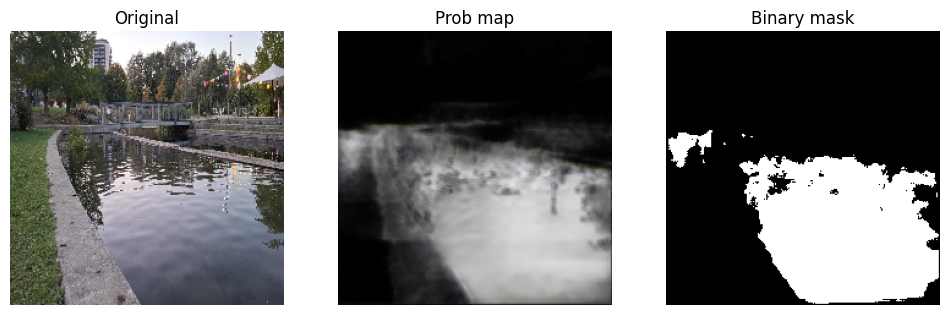

 10%|▉         | 701/7039 [06:13<1:07:38,  1.56it/s]

No water: 287


 12%|█▏        | 840/7039 [10:11<59:48:39, 34.73s/it]

Index 840, fraction positive mask = 0.1012
saved


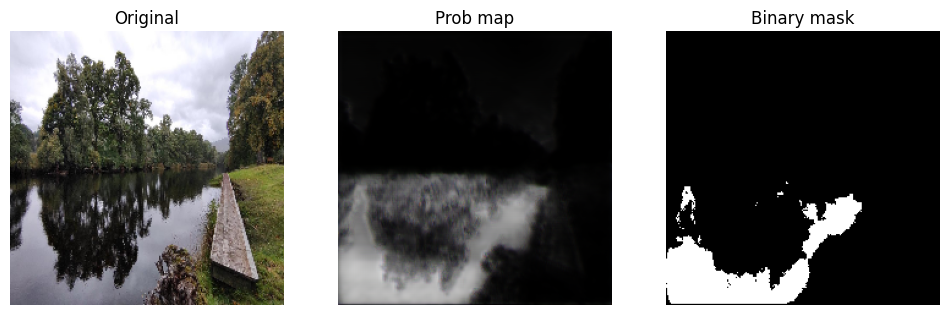

 12%|█▏        | 841/7039 [10:12<42:06:00, 24.45s/it]

No water: 348


 14%|█▍        | 980/7039 [11:00<32:27,  3.11it/s]   

Index 980, fraction positive mask = 0.0673


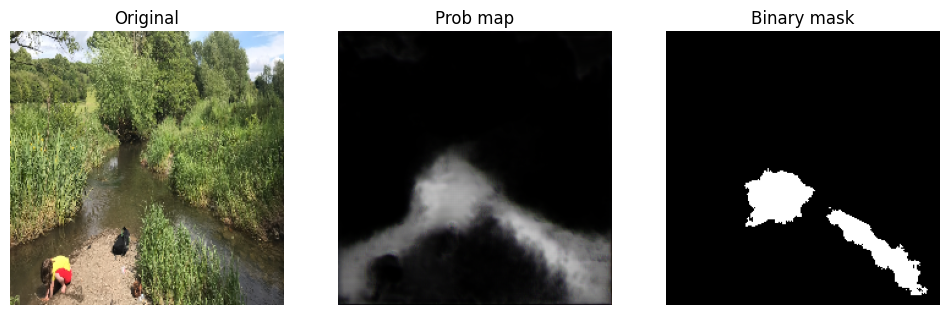

 14%|█▍        | 981/7039 [11:01<37:14,  2.71it/s]

No water: 403


 16%|█▌        | 1120/7039 [11:49<51:00,  1.93it/s]

Index 1120, fraction positive mask = 0.0091


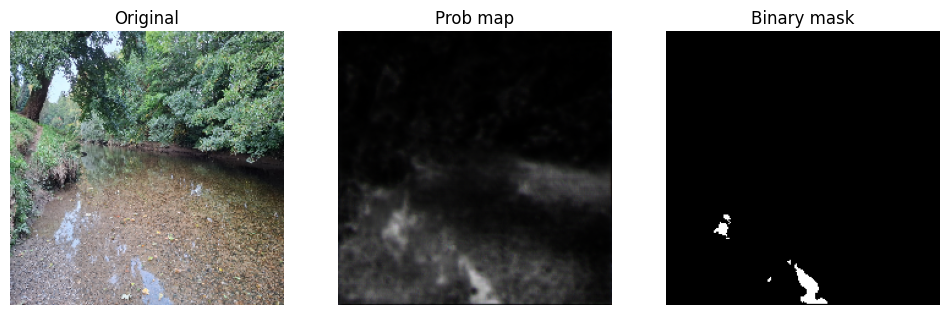

 16%|█▌        | 1121/7039 [11:49<50:07,  1.97it/s]

No water: 462


 18%|█▊        | 1260/7039 [12:42<31:09,  3.09it/s]  

Index 1260, fraction positive mask = 0.1202
saved


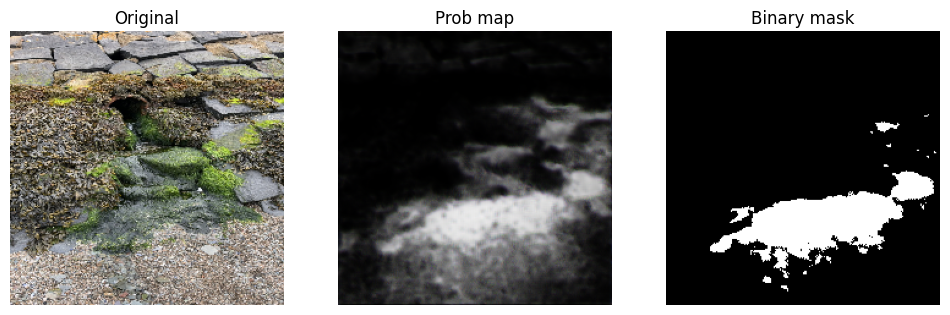

 18%|█▊        | 1261/7039 [12:43<36:07,  2.67it/s]

No water: 520


 20%|█▉        | 1400/7039 [13:48<44:39,  2.10it/s]  

Index 1400, fraction positive mask = 0.0000


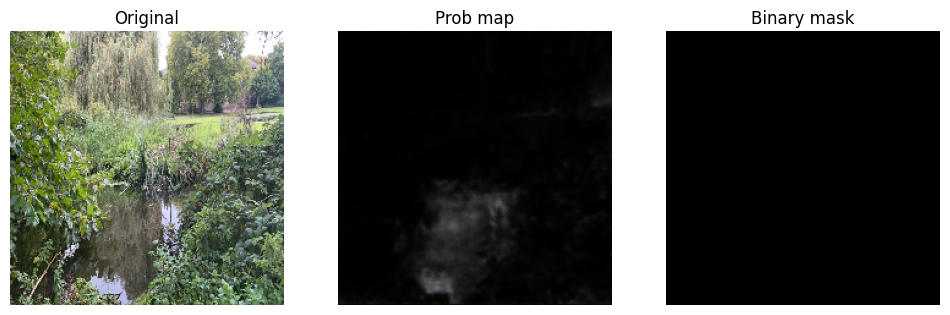

 20%|█▉        | 1401/7039 [13:48<51:15,  1.83it/s]

No water: 581


 22%|██▏       | 1540/7039 [15:00<43:32,  2.11it/s]  

Index 1540, fraction positive mask = 0.1158
saved


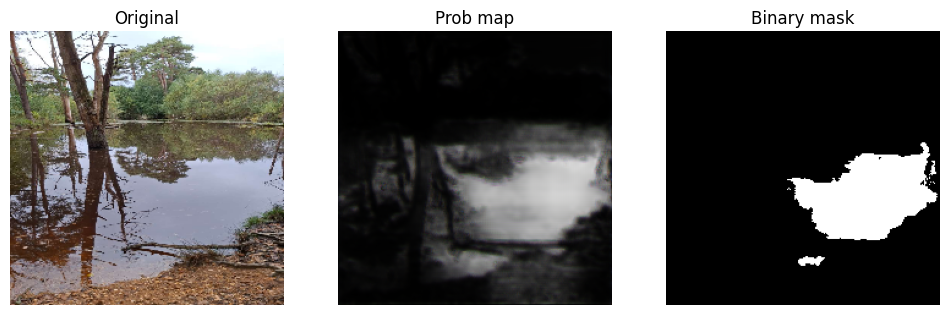

 22%|██▏       | 1541/7039 [15:01<50:44,  1.81it/s]

No water: 637


 24%|██▍       | 1680/7039 [16:18<54:33,  1.64it/s]  

Index 1680, fraction positive mask = 0.0227


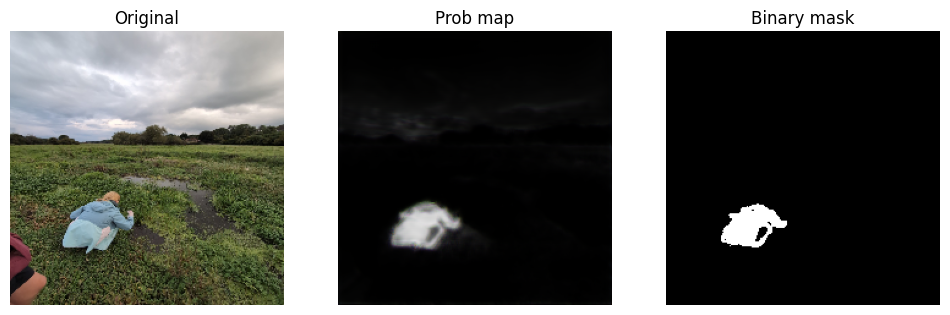

 24%|██▍       | 1681/7039 [16:19<58:52,  1.52it/s]

No water: 692


 26%|██▌       | 1820/7039 [17:25<38:01,  2.29it/s]

Index 1820, fraction positive mask = 0.1124
saved


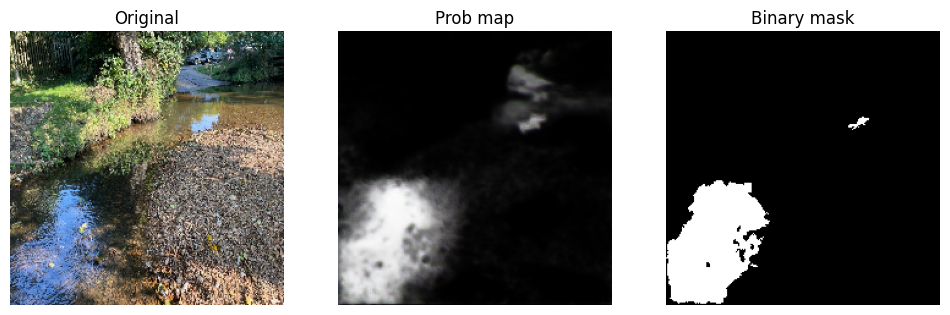

 26%|██▌       | 1821/7039 [17:25<44:08,  1.97it/s]

No water: 748


 28%|██▊       | 1960/7039 [18:35<39:04,  2.17it/s]  

Index 1960, fraction positive mask = 0.1002
saved


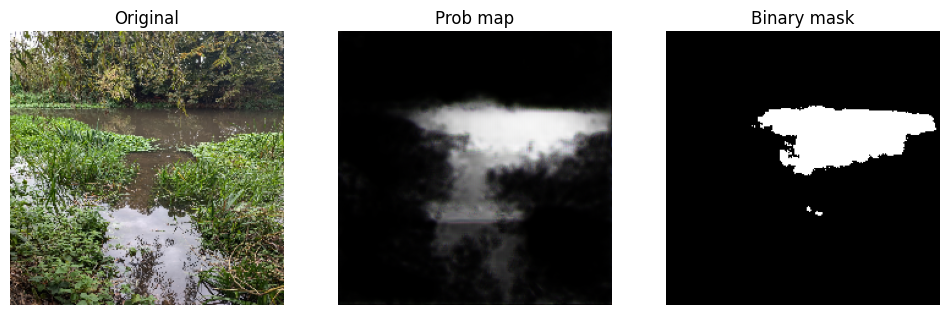

 28%|██▊       | 1961/7039 [18:35<43:51,  1.93it/s]

No water: 810


 30%|██▉       | 2100/7039 [19:44<39:00,  2.11it/s]

Index 2100, fraction positive mask = 0.3508
saved


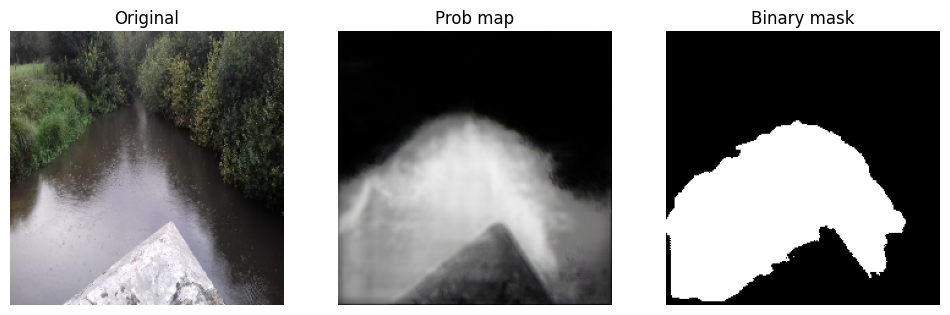

 30%|██▉       | 2101/7039 [19:45<44:39,  1.84it/s]

No water: 858


 32%|███▏      | 2240/7039 [20:54<38:24,  2.08it/s]

Index 2240, fraction positive mask = 0.2636
saved


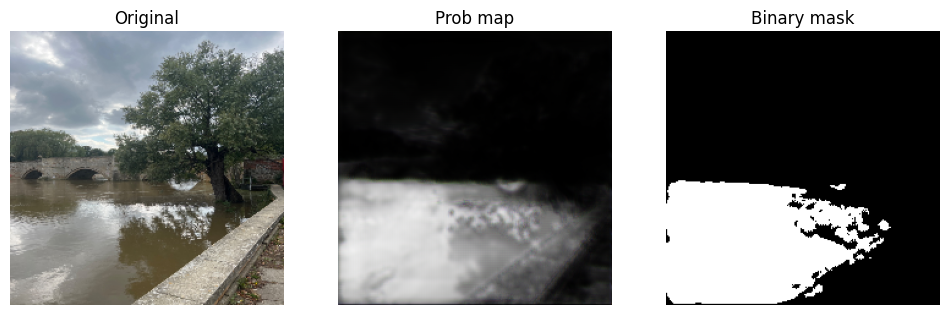

 32%|███▏      | 2241/7039 [20:55<44:04,  1.81it/s]

No water: 916


 33%|███▎      | 2326/7039 [27:45<56:13,  1.40it/s]     


KeyboardInterrupt: 

In [8]:
#This part of the code filters the image dataset by how much water they contain, saving the images and masks to different files and also displays some examples. 

#User Settings
out_dir = "/home/teaching/earthwatch-cnn/results/selected_by_mask_10"  # where to save selected images
csv_path = os.path.join(out_dir, "mask_fractions.csv")
save_fraction_threshold = 0.10   # save images whose mask fraction > 15%
prob_threshold = 0.5            # pixel-level probability threshold used to create binary mask

#Creat directories to save the filtered pictures in, and also the predicted and binary masks. 
os.makedirs(out_dir, exist_ok=True)
os.makedirs(os.path.join(out_dir, "originals"), exist_ok=True)
os.makedirs(os.path.join(out_dir, "pred_masks"), exist_ok=True)
os.makedirs(os.path.join(out_dir, "binary_masks"), exist_ok=True)

fractions = []   # store (index, path, fraction)
n_files = len(X_values)
#Checkpoints
delta_checkpoints = max(1, n_files // 50)
checkpoints = set(np.arange(0, n_files, delta_checkpoints))
no_water=0

for i in tqdm(range(n_files)):
    image = X_values[i]                      # shape (224,224,3), floats in [0,1] assumed
    pred_mask = UNet.predict(np.expand_dims(image, axis=0), verbose=0)[0]  # e.g. (224,224,channels)
    prob_map = pred_mask
    binary_mask = (pred_mask[:,:,0] > 0.5).astype('int')

    #Fraction of pixels that are positive (
    frac = binary_mask.mean()   
    fractions.append((i, my_paths[i], float(frac)))

    #Save images if fraction exceeds threshold
    if frac > save_fraction_threshold:
        #Filenames
        base = f"{i:05d}"  #zero-padded index
        orig_fn = os.path.join(out_dir, "originals", base + ".png")
        pred_fn = os.path.join(out_dir, "pred_masks", base + "_pred.png")
        bin_fn  = os.path.join(out_dir, "binary_masks", base + "_bin.png")

        #Save original image (assumes image in [0,1])
        plt.imsave(orig_fn, np.clip(image, 0, 1))

        #Save predicted probability map as a colored heatmap for visualization
        #Normalize prob_map to 0..1 then map with a colormap
        plt.imsave(pred_fn, (binary_mask * 255).astype(np.uint8), cmap="gray")

        # Save binary mask as grayscale (0 or 255)
        plt.imsave(bin_fn, (binary_mask * 255).astype(np.uint8), cmap="gray")
    else:
        no_water+=1
    #Displaying examples
    if i in checkpoints:
        print(f"Index {i}, fraction positive mask = {frac:.4f}")
        if frac > save_fraction_threshold:
            print("saved")
        plt.figure(figsize=(12,4))
        plt.subplot(1,3,1); plt.title("Original"); plt.axis("off"); plt.imshow(np.clip(image,0,1))
        plt.subplot(1,3,2); plt.title("Prob map"); plt.axis("off"); plt.imshow(prob_map, cmap="viridis")
        plt.subplot(1,3,3); plt.title("Binary mask"); plt.axis("off"); plt.imshow(binary_mask, cmap="gray")
        plt.show()
        print(f"No water: {no_water}")

#Write CSV with fractions
with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["index", "path", "mask_fraction"])
    for rec in fractions:
        writer.writerow(rec)

#Compute summary stats
all_fracs = np.array([r[2] for r in fractions])
n_above = (all_fracs > save_fraction_threshold).sum()
n_below = (all_fracs <= save_fraction_threshold).sum()

print(f"Saved images with mask fraction > {save_fraction_threshold:.3f} to {out_dir}")
print(f"Total images: {n_files}; Above threshold: {n_above}; Below or equal: {n_below}")
print(f"CSV of fractions saved to: {csv_path}")